This secion was ran using Google Colab, the DATASET has to be uploaded to the sample_data file. in order for the program to output.


In [ ]:
# @title Install DeepFace & other dependencies
!pip install numpy
!pip install matplotlib
!pip install opencv-python
!pip install deepface

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 53.9 MB/s eta 0:00:00
  Created wheel for fire: filename=fire-0.7.0-py3-none-any.whl size=114249 sha256=2929a106cb759cd2d16a754bee0bb23e7ee2b4741691b3c94835f40d0d434b0a
  Stored in directory: /root/.cache/pip/wheels/46/54/24/1624fd5b8674eb1188623f7e8e17cdf7c0f6c24b609dfb8a89
Successfully built fire


In [ ]:
# @title Import DeepFace
from deepface import DeepFace
import matplotlib.pyplot as plt
import cv2
import numpy as np
from zipfile import ZipFile
import os

25-05-19 16:56:54 - Directory /root/.deepface has been created
25-05-19 16:56:54 - Directory /root/.deepface/weights has been created


In [ ]:
from google.colab import files
os.chdir("/content/sample_data")
uploaded = files.upload()

In [ ]:
print(os.getcwd())
os.chdir("/content/sample_data")
# Resource used for getting data from zipped file: https://www.geeksforgeeks.org/unzipping-files-in-python/
zip_path = 'DATASET.zip'
extract_path = '/content/sample_data'

# loading the temp.zip and creating a zip object
with ZipFile(zip_path, 'r') as zObject:
	# Extracting all the members of the zip
	# into a specific location.
	zObject.extractall(
		path=extract_path)

In [ ]:
class testingDataset():
  def __init__(self, path):
    self.path = path
    self.globalAccuracy = 0
    self.emotion_labels = {
        'surprise' : {},
        'fear' : {},
        'disgust' : {},
        'happy' : {},
        'sad' : {},
        'angry' : {},
        'neutral' : {}
    }

  def print_dataset_metrics(self):
    print(self.globalAccuracy)
    print(self.emotion_labels)


In [ ]:
import os
from deepface import DeepFace
import numpy as np

# @title Defining testing function for datasets
def test_dataset(testingDatasetObject):
    dataset_emotions_labels = {
      'surprise': {},
      'fear': {},
      'disgust': {},
      'happy': {},
      'sad': {},
      'angry': {},
      'neutral': {}
      }

    # Dictionary mapping folder number to emotion
    emotion_labels = {
      '5': 'surprise',
      '2': 'fear',
      '1': 'disgust',
      '3': 'happy',
      '4': 'sad',
      '0': 'angry',
      '6': 'neutral'
    }

    # Global accuracy metrics
    total_images = 0
    correct_predictions = 0

    # Iterate through each folder, testing the accuracy of DeepFace
    for folder_name, emotion in emotion_labels.items():
      folder_path = os.path.join(testingDatasetObject.path, folder_name)

      print(f"Processing folder {folder_name}: {emotion}")

      # Local accuracy metrics (per-class)
      classPrediction = 0
      classTotal = 0

      emotions = {
          'surprise': 0,
          'fear': 0,
          'disgust': 0,
          'happy': 0,
          'sad': 0,
          'angry': 0,
          'neutral': 0
      }

      # Iterate through images in the folder
      for image_name in os.listdir(folder_path):
          image_path = os.path.join(folder_path, image_name)
          try:
              # DeepFace facial attribute analysis
              result = DeepFace.analyze(img_path=image_path, actions=['emotion'], enforce_detection=False)
              prediction = result[0]['dominant_emotion']

              # Update global accuracy metrics
              total_images += 1
              classTotal += 1
              emotions[prediction.lower()] += 1
              if prediction.lower() == emotion.lower():
                  correct_predictions += 1
                  classPrediction += 1

          except Exception as e:
              print(f"Error processing {image_name}: {e}")

      classAccuracy = (classPrediction/classTotal) * 100
      print(emotions)
      print(f"Finished processing folder {folder_name}: {emotion} class accuracy: {classAccuracy:.2f}%")
      dataset_emotions_labels[emotion] = emotions
    # Calculate and display accuracy
    accuracy = (correct_predictions / total_images) * 100
    print(f"Accuracy: {accuracy:.2f}%")
    testingDatasetObject.globalAccuracy = accuracy
    testingDatasetObject.emotion_labels = dataset_emotions_labels

trainset = testingDataset('/content/sample_data/DATASET/train')
test_dataset(trainset)
trainset.print_dataset_metrics()

Processing folder 5: surprise
{'surprise': 101, 'fear': 75, 'disgust': 0, 'happy': 33, 'sad': 37, 'angry': 79, 'neutral': 100}
Finished processing folder 5: surprise class accuracy: 23.76%
Processing folder 2: fear
{'surprise': 13, 'fear': 45, 'disgust': 1, 'happy': 67, 'sad': 90, 'angry': 92, 'neutral': 74}
Finished processing folder 2: fear class accuracy: 11.78%
Processing folder 1: disgust
{'surprise': 0, 'fear': 15, 'disgust': 25, 'happy': 58, 'sad': 67, 'angry': 218, 'neutral': 23}
Finished processing folder 1: disgust class accuracy: 6.16%
Processing folder 3: happy
{'surprise': 1, 'fear': 5, 'disgust': 0, 'happy': 391, 'sad': 11, 'angry': 2, 'neutral': 6}
Finished processing folder 3: happy class accuracy: 93.99%
Processing folder 4: sad
{'surprise': 0, 'fear': 9, 'disgust': 7, 'happy': 15, 'sad': 233, 'angry': 49, 'neutral': 69}
Finished processing folder 4: sad class accuracy: 60.99%
Processing folder 0: angry
{'surprise': 0, 'fear': 12, 'disgust': 7, 'happy': 12, 'sad': 90, 

In [ ]:
print("-----------------------------------------------------------")
print('test split')
testset = testingDataset('/content/sample_data/DATASET/test')
test_dataset(testset)
testset.print_dataset_metrics()
print("-----------------------------------------------------------")
print('validation split')
valset = testingDataset('/content/sample_data/DATASET/validation')
test_dataset(valset)
valset.print_dataset_metrics()

-----------------------------------------------------------
test split
Processing folder 5: surprise
{'surprise': 10, 'fear': 10, 'disgust': 0, 'happy': 2, 'sad': 6, 'angry': 10, 'neutral': 16}
Finished processing folder 5: surprise class accuracy: 18.52%
Processing folder 2: fear
{'surprise': 2, 'fear': 6, 'disgust': 0, 'happy': 6, 'sad': 14, 'angry': 12, 'neutral': 8}
Finished processing folder 2: fear class accuracy: 12.50%
Processing folder 1: disgust
{'surprise': 0, 'fear': 3, 'disgust': 1, 'happy': 12, 'sad': 10, 'angry': 22, 'neutral': 3}
Finished processing folder 1: disgust class accuracy: 1.96%
Processing folder 3: happy
{'surprise': 0, 'fear': 0, 'disgust': 0, 'happy': 48, 'sad': 3, 'angry': 0, 'neutral': 1}
Finished processing folder 3: happy class accuracy: 92.31%
Processing folder 4: sad
{'surprise': 0, 'fear': 0, 'disgust': 2, 'happy': 3, 'sad': 31, 'angry': 6, 'neutral': 6}
Finished processing folder 4: sad class accuracy: 64.58%
Processing folder 0: angry
{'surprise': 

In [ ]:
# @title Percentages
validaiton = {'surprise': {'surprise': 16, 'fear': 12, 'disgust': 0, 'happy': 5, 'sad': 4, 'angry': 6, 'neutral': 10},
              'fear': {'surprise': 1, 'fear': 5, 'disgust': 1, 'happy': 10, 'sad': 11, 'angry': 9, 'neutral': 10},
              'disgust': {'surprise': 0, 'fear': 1, 'disgust': 3, 'happy': 10, 'sad': 4, 'angry': 28, 'neutral': 5},
              'happy': {'surprise': 0, 'fear': 1, 'disgust': 0, 'happy': 49, 'sad': 1, 'angry': 0, 'neutral': 1},
              'sad': {'surprise': 0, 'fear': 4, 'disgust': 0, 'happy': 2, 'sad': 28, 'angry': 5, 'neutral': 9},
              'angry': {'surprise': 0, 'fear': 3, 'disgust': 0, 'happy': 0, 'sad': 9, 'angry': 28, 'neutral': 9},
              'neutral': {'surprise': 0, 'fear': 1, 'disgust': 0, 'happy': 5, 'sad': 19, 'angry': 10, 'neutral': 69}
         }

test = {'surprise': {'surprise': 10, 'fear': 10, 'disgust': 0, 'happy': 2, 'sad': 6, 'angry': 10, 'neutral': 16},
        'fear': {'surprise': 2, 'fear': 6, 'disgust': 0, 'happy': 6, 'sad': 14, 'angry': 12, 'neutral': 8},
        'disgust': {'surprise': 0, 'fear': 3, 'disgust': 1, 'happy': 12, 'sad': 10, 'angry': 22, 'neutral': 3},
        'happy': {'surprise': 0, 'fear': 0, 'disgust': 0, 'happy': 48, 'sad': 3, 'angry': 0, 'neutral': 1},
        'sad': {'surprise': 0, 'fear': 0, 'disgust': 2, 'happy': 3, 'sad': 31, 'angry': 6, 'neutral': 6},
        'angry': {'surprise': 0, 'fear': 0, 'disgust': 1, 'happy': 3, 'sad': 12, 'angry': 22, 'neutral': 12},
        'neutral': {'surprise': 0, 'fear': 3, 'disgust': 0, 'happy': 5, 'sad': 27, 'angry': 16, 'neutral': 54}
        }

train = {'surprise': {'surprise': 101, 'fear': 75, 'disgust': 0, 'happy': 33, 'sad': 37, 'angry': 79, 'neutral': 100},
         'fear': {'surprise': 13, 'fear': 45, 'disgust': 1, 'happy': 67, 'sad': 90, 'angry': 92, 'neutral': 74},
         'disgust': {'surprise': 0, 'fear': 15, 'disgust': 25, 'happy': 58, 'sad': 67, 'angry': 218, 'neutral': 23},
         'happy': {'surprise': 1, 'fear': 5, 'disgust': 0, 'happy': 391, 'sad': 11, 'angry': 2, 'neutral': 6},
         'sad': {'surprise': 0, 'fear': 9, 'disgust': 7, 'happy': 15, 'sad': 233, 'angry': 49, 'neutral': 69},
         'angry': {'surprise': 0, 'fear': 12, 'disgust': 7, 'happy': 12, 'sad': 90, 'angry': 213, 'neutral': 62},
         'neutral': {'surprise': 0, 'fear': 10, 'disgust': 0, 'happy': 18, 'sad': 208, 'angry': 69, 'neutral': 529}
         }



def get_percentages(split, name):
  # Split is dictionary of dictionaries
  print(name)
  for key in split.keys():
    # print(key)
    key_dict = split[key]
    print(key_dict)
    key_total = 0
    for value in key_dict.values():
      key_total += value

    for value in key_dict.keys():
      key_dict[value] = round((key_dict[value] / key_total) * 100, 2
                              )
    print(key +' '+ str(key_dict))
  print('--------------------------------------------------------------------')

def get_total(split, split2, split3, name):
  # Split is dictionary of dictionaries
  print(name)
  overall_total = 0


  correct_pred =  0
  for key in split.keys():

    key_dict = split[key]
    split2_key_dict = split2[key]
    split3_key_dict = split3[key]

    # Gets total of all keys
    key_total = 0
    for value in key_dict.values():
      key_total += value

    for value in split2_key_dict.values():
      key_total += value

    for value in split3_key_dict.values():
      key_total += value


    for value in key_dict.keys():
      if value == key:
        correct_pred += key_dict[value] + split2_key_dict[value] + split3_key_dict[value]
      total = key_dict[value] + split2_key_dict[value] + split3_key_dict[value]
      key_dict[value] = total
      key_dict[value] = round((total / key_total) * 100, 2)
    print(key +': '+ str(key_dict) +',')
    overall_total += key_total
  print('--------------------------------------------------------------------')
  print(str(round((correct_pred/overall_total)*100,2)) + '% Accuracy')
  print('--------------------------------------------------------------------')

get_total(train, test, validaiton, 'total')





import pandas as pd

combined = {
'surprise': {'surprise': 23.87, 'fear': 18.23, 'disgust': 0.0, 'happy': 7.52, 'sad': 8.83, 'angry': 17.86, 'neutral': 23.68},
'fear': {'surprise': 3.35, 'fear': 11.74, 'disgust': 0.42, 'happy': 17.4, 'sad': 24.11, 'angry': 23.69, 'neutral': 19.29},
'disgust': {'surprise': 0.0, 'fear': 3.74, 'disgust': 5.71, 'happy': 15.75, 'sad': 15.94, 'angry': 52.76, 'neutral': 6.1},
'happy': {'surprise': 0.19, 'fear': 1.15, 'disgust': 0.0, 'happy': 93.85, 'sad': 2.88, 'angry': 0.38, 'neutral': 1.54},
'sad': {'surprise': 0.0, 'fear': 2.72, 'disgust': 1.88, 'happy': 4.18, 'sad': 61.09, 'angry': 12.55, 'neutral': 17.57},
'angry': {'surprise': 0.0, 'fear': 3.03, 'disgust': 1.62, 'happy': 3.03, 'sad': 22.42, 'angry': 53.13, 'neutral': 16.77},
'neutral': {'surprise': 0.0, 'fear': 1.34, 'disgust': 0.0, 'happy': 2.68, 'sad': 24.35, 'angry': 9.11, 'neutral': 62.51},
}


df = pd.DataFrame.from_dict(combined, orient='index').reset_index()
print(df)




total
surprise: {'surprise': 23.87, 'fear': 18.23, 'disgust': 0.0, 'happy': 7.52, 'sad': 8.83, 'angry': 17.86, 'neutral': 23.68},
fear: {'surprise': 3.35, 'fear': 11.74, 'disgust': 0.42, 'happy': 17.4, 'sad': 24.11, 'angry': 23.69, 'neutral': 19.29},
disgust: {'surprise': 0.0, 'fear': 3.74, 'disgust': 5.71, 'happy': 15.75, 'sad': 15.94, 'angry': 52.76, 'neutral': 6.1},
happy: {'surprise': 0.19, 'fear': 1.15, 'disgust': 0.0, 'happy': 93.85, 'sad': 2.88, 'angry': 0.38, 'neutral': 1.54},
sad: {'surprise': 0.0, 'fear': 2.72, 'disgust': 1.88, 'happy': 4.18, 'sad': 61.09, 'angry': 12.55, 'neutral': 17.57},
angry: {'surprise': 0.0, 'fear': 3.03, 'disgust': 1.62, 'happy': 3.03, 'sad': 22.42, 'angry': 53.13, 'neutral': 16.77},
neutral: {'surprise': 0.0, 'fear': 1.34, 'disgust': 0.0, 'happy': 2.68, 'sad': 24.35, 'angry': 9.11, 'neutral': 62.51},
--------------------------------------------------------------------
47.05% Accuracy
-------------------------------------------------------------------

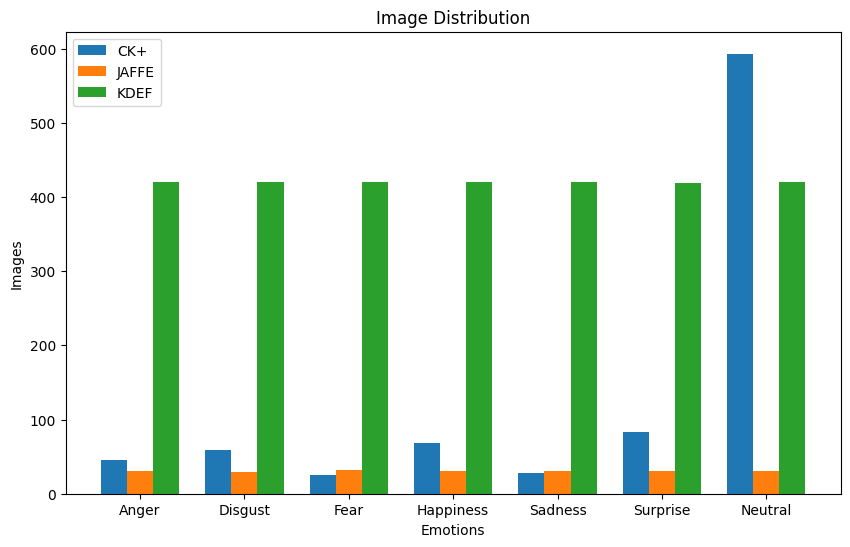

In [ ]:
# @title BAR CHART FOR DATA DISTRIBUTION
import matplotlib.pyplot as plt
import numpy as np

emotions = ['Anger', 'Disgust', 'Fear', 'Happiness', 'Sadness','Surprise','Neutral' ]
ck = [45,59,25,69,28,83,593]
jaffe = [30,29,32,31,31,30,30]
kdef = [420,420,420,420,420,419,420]

x = np.arange(len(emotions))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, ck, width, label='CK+')
plt.bar(x, jaffe, width, label='JAFFE')
plt.bar(x + width, kdef, width, label='KDEF')

plt.xlabel('Emotions')
plt.ylabel('Images')
plt.title('Image Distribution')
plt.xticks(x, emotions)
plt.legend()

plt.show()